<a href="https://colab.research.google.com/github/Marcehlin/Notes-Marcelo/blob/main/Trabalho_Amostragem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho Amostragem**


* Marcelo Xinhong Huang - RA: 832111

* Leticia Yumi Ichibara - RA: 834396

* Pedro Henrique de Araujo - RA: 831235

## **1. Introdução**

Este é um trabalho sobre **Amostragem Aleatória Simples (AAS)** e **Amostragem Estratificada (AES)**.

Iremos realizar dois tipos de amostragens distintas na base de dados fornecida com as respostas do questionário aplicado aos indivíduos que realizaram o processo seletivo.

Desse modo, o trabalho tem como objetivo, através de dois planos amostrais distintos, coletar amostras das pessoas que responderam o questionário e estimar o número de pessoas que passaram para a 2ª fase do processo seletivo.

A variável de interesse do nosso trabalho é a variável binária $Y_i =
\begin{cases}
1, & \text{se o indivíduo } i \text{ foi aprovado} \\
0, & \text{caso contrário}
\end{cases}$.

Logo, os parâmetros são:

* $N_A$: total de pessoas aprovadas para 2ª fase;

* $p$: proporção das pessoas aprovadas para 2ª fase.

## **2. Amostragem Aleatória Simples Sem Reposição (AASs)**

O primeiro plano amostral que usaremos será a **Amostragem Aleatória Simple**s, na qual todos os indivíduos terão a mesma probabilidade de ser sorteada para fazer parte da amostra, sem reposição daqueles que já foram sorteados.
Como o total de indivíduos que realizaram a pesquisa é $N = 73498$, a probabilidade de cada indivíduo ser sorteado é de $\frac{1}{73498}$.

Escolhemos esse como primeiro plano amostral pois é um plano básico e simples de ser realizado, resultando, geralmente, em estimadores concisos.

Primeiramente, para começar a amostragem, iremos calcular o tamanho da amostra $n$ necessário para atingir certa precisão. No nosso caso, obtamos por calcular o tamanho amostral baseado na proporção populacional, além de escolher uma margem de erro de $D = 2\%$ e um intervalo de $95\%$ de confiança.

Desse modo, $n$ será dado por:
$$
n = \frac{n_0}{1+n_0/N},
$$
onde $n_0$ é calculado por:
$$
n_0 = \frac{z_{\alpha/2}^2 p(1-p)}{D^2}
$$

In [ ]:
#Bibliotecas utilizadas
install.packages("gridExtra")
library(ggplot2)
library(gridExtra)
library(readr)     # Para ler CSV
library(readxl)    # Para ler XLSX
library(dplyr)     # Para manipulação de dados
library(tidyr)    # Para organizar dados (se necessário)
set.seed(789)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Criando um data frame com base no arquivo .txt do questionário
dados <- read_delim("Respostas_Questionário.txt",
                        delim = ";",
                        col_names = TRUE)

Rows: 73498 Columns: 50
── Column specification ────────────────────────────────────────────────────────
Delimiter: ";"
chr  (1): APROVA1
dbl (48): Q1, Q2, Q3, Q4, Q5, Q6, Q7, Q8, Q9, Q10, Q11, Q12, Q13, Q14, Q15, ...
num  (1): empct

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
#Cálculo dos parâmetros

N <- nrow(dados)
cat('Tamanho da população:', N, '\n')

Y <- sum(dados$APROVA1 == "S",na.rm = TRUE)
cat('Número de pessoas aprovadas para a 2ª fase:', Y, '\n')

#table(dados$APROVA1)
Y_barra <- Y / N
cat('Proporção de pessoas que passaram para a 2ª fase:', Y_barra, '\n')

gamma <-  0.95
z <- qnorm((1+gamma)/2)
D <- 0.02

n0 <- z^2 * Y_barra*(1-Y_barra) / D^2
n <- ceiling(n0/(1+n0/N))
cat('TAMANHO DA AMOSTRA: n =', n)

Tamanho da população: 73498 
Número de pessoas aprovadas para a 2ª fase: 15390 
Proporção de pessoas que passaram para a 2ª fase: 0.2093935 
TAMANHO DA AMOSTRA: n = 1557

Com base nisso, temos que os parâmetros são:
* $N = 73498$
* $N_A$ = $15390$
* $p \approx 0,209$

Como resultado, temos que o tamanho da amostra será de $n = 1557$.
Então, podemos realizar a amostragem.

In [ ]:
#Amostragem

ids_sorteados <- sample(dados$empct, size = n)

dados_amostra_AAS <- dados %>%
  filter(empct %in% ids_sorteados)

Realizada a amostragem, devemos realizar a estimação dos parâmetros populacionais. Os estimadores para a AASs que escolhemos são:
* Estimador para a proporção: $\hat{p} = n_A/n$
* Estimador para o total: $\hat{N}_A = N\hat{p}$

E as variâncias desses dois estimadorestambém podem ser calculadas:
* ${V}_{AAS}(\hat{p}) =
(\frac{1}{n} - \frac{1}{N})\frac{n{p}(1-{p})}{n-1}$

* ${V}_{AAS}(\hat{N}_A)= N^2{V}_{AAS}(\hat{p})$

Note que as duas expressões acima dependem da variância populacional, pois como possuimos as informações populacionais, podemos calculá-las. Caso a variância populacional fosse desconhecida, poderíamos estimar as variâncias:
* Estimador para a variância do estimador para proporção: $\hat{V}_{AAS}(\hat{p}) =
(\frac{1}{n} - \frac{1}{N})\frac{n\hat{p}(1-\hat{p})}{n-1}$
* Estimador para a variância do estimador para total: $\hat{V}_{AAS}(\hat{N}_A)= N^2\hat{V}_{AAS}(\hat{p})$


In [ ]:
#Cálculo dos estimadores

total_amostra <- sum(dados_amostra_AAS$APROVA1 == "S",na.rm = TRUE)
cat('n_a =', total_amostra, '\n')

y_barra <- total_amostra / n
cat('Estimador para a proporção:', y_barra, '\n')

Y_chapeu <- N*y_barra
cat('Estimador para o total:', Y_chapeu, '\n')

var_Y_barra <- (1/n - 1/N)*(n/(n-1))*Y_barra*(1-Y_barra)

cat('Variância do estimador para proporção:', var_Y_barra, '\n')

var_Y_chapeu <- N^2*(1/n - 1/N)*(n/(n-1))*Y_barra*(1-Y_barra)
cat('Variância do estimador para total:', var_Y_chapeu, '\n')

n_a = 346 
Estimador para a proporção: 0.2222222 
Estimador para o total: 16332.89 
Variância do estimador para proporção: 0.0001041393 
Variância do estimador para total: 562556.2 


Então,
* $\hat{p} \approx 0,222$
* $\hat{N}_A \approx 16333$
* ${V}_{AAS}(\hat{p}) \approx 0,0001$
* ${V}_{AAS}(\hat{N}_A) = 562556,2$

Podemos, também, calcular os intervalos de $95\%$ de confiança para a proporção e total populacionais. Eles podem ser calculados pela fórmulas:
* IC(${p}; 95\%$) = $\hat{p} \pm z_{0,975}^2 \cdot \sqrt{{V}_{AAS}(\hat{p})}$
* IC(${N}_A; 95\%$) = $\hat{N}_A \pm z_{0,975}^2 \cdot \sqrt{{V}_{AAS}(\hat{N}_A)}$

In [ ]:
#Cálculo dos intervalos de confiança


IC_Y <- c(Y_chapeu - z*sqrt(var_Y_chapeu),Y_chapeu + z*sqrt(var_Y_chapeu))
IC_Y_barra <- c(y_barra - z*sqrt(var_y_barra),y_barra + z*sqrt(var_y_barra))

cat("Intervalo de confiança para Y(total de aprovados):", IC_Y, "\n")
cat("Intervalo de confiança para Y_barra(proporção):", IC_Y_barra, "\n")

Intervalo de confiança para Y(total de aprovados): 14862.84 17802.94 
Intervalo de confiança para Y_barra(proporção): 0.202221 0.2422234 


Então,
* $IC({N}_A; 95\%) = [14862,84; 17802,94]$;
* $IC({p}; 95\%) \approx [0,202; 0,242]$

## **3. Amostragem Estratificada (AES)**

O segundo plano amostral que escolhemos é a **Amostragem Estratificada**. Ela consiste em utilizar uma variável de interesse para dividir a população em estratos, isto é, $H$ grupos disjuntos e homogêneos em relação à variável escolhida. Em seguida, é feita uma AASs em cada um dos estratos, fazendo com que a amostra final seja a união das amostras de cada um dos estratos.

Escolhemos esse plano amostral pois, no questionário aplicado, é natural que em diversas questões possa se obter variáveis que dividam a população em grupos homogêneos.
Para nossa amostragem, escolhemos como variável de interesse a renda familiar mensal, baseada na resposta da Questão 14 do questionário.

Então, os estratos formados serão, considerando que 1 salário mínimo (SM) é 724 reais:
* $U_1:$ pessoas que não responderam a questão
* $U_2:$ pessoas com renda familiar mensal inferior a 01 SM
* $U_3:$ pessoas com renda familiar entre 01 e 02 SM
* $U_4:$ pessoas com renda familiar entre 02 e 03 SM
* $U_5:$ pessoas com renda familiar entre 03 e 05 SM
* $U_6:$ pessoas com renda familiar entre 05 e 07 SM
* $U_7:$ pessoas com renda familiar entre 07 e 10 SM
* $U_8:$ pessoas com renda familiar entre 10 e 15 SM
* $U_9:$ pessoas com renda familiar entre 15 e 20 SM
* $U_{10}:$ pessoas com renda familiar acima de 20 SM

**OBS:**  No arquivo 'Respostas_Questionários.txt', valor '0' é atribuído para pessoas que não responderam, e essas pessoas constituem o estrato 1. Logo valor '1' é do estrato 2, assim por diante.



In [ ]:
# Dividindo a população em estratos

table(dados$Q14)
Estratos <- split(dados, dados$Q14)


    0     1     2     3     4     5     6     7     8     9 
 1332   891  6814  9567 15478 12093  9735  7926  4058  5604 

In [ ]:
cat("TABELA 1: Número de aprovados em cada estrato \n")
print(tabela_aprovados_estratos_completa, n = 10)

TABELA 1: Número de aprovados em cada estrato 
# A tibble: 10 × 4
   Estrato Tamanho_Estrato Aprovados_Populacao Proporcao_Aprovados
     <int>           <dbl>               <dbl>               <dbl>
 1       1            1332                 323                0.24
 2       2             891                 151                0.17
 3       3            6814                 932                0.14
 4       4            9567                1491                0.16
 5       5           15478                2890                0.19
 6       6           12093                2540                0.21
 7       7            9735                2261                0.23
 8       8            7926                2062                0.26
 9       9            4058                1094                0.27
10      10            5604                1646                0.29


Para realizar a amostra de cada um dos estratos, utilizaremos uma amostra total de tamanho $n = 1557$, assim como na AASs, para fins de comparações posteriores. Além disso, utilizaremos a alocação proporcional para decidir o tamanho de cada estrato, de modo que o tamanho de cada estrato seja tal que $n_h = n \cdot N_h / N$, em que $n_h$ é o tamanho da amostra do estrato $H$, para $H = 1,2,\cdots,10$.
Então,

In [ ]:
#Amostragem de cada estrato


n <- 1557 #usando o mesmo tamanho amostral de AAS para comparar depois a eficiência

nh <- NULL
Nh <- NULL
Yh <- NULL
amostras_AES <- NULL

for (i in 0:9){
    Nh[as.character(i)] <- nrow(Estratos[[as.character(i)]])
    nh[as.character(i)] <- round(n*nrow(Estratos[[as.character(i)]])/N)

    ids_sorteados <- sample(Estratos[[as.character(i)]]$empct, size = nh[as.character(i)])
    amostras_AES[[as.character(i)]] <- Estratos[[as.character(i)]] %>%
     filter(empct %in% ids_sorteados)
}

In [ ]:
cat("TABELA 2: Número de aprovados em cada amostra dos estratos \n")
print(tabela_aprovados_amostra_completa, n = 10)

TABELA 2: Número de aprovados em cada amostra dos estratos 
# A tibble: 10 × 4
   Estrato Tamanho_Amostra Aprovados_Amostra Prop_Aprovados
     <int>           <dbl>             <dbl>          <dbl>
 1       1              28                 5           0.18
 2       2              19                 5           0.26
 3       3             144                17           0.12
 4       4             203                32           0.16
 5       5             328                62           0.19
 6       6             256                55           0.21
 7       7             206                50           0.24
 8       8             168                46           0.27
 9       9              86                31           0.36
10      10             119                27           0.23


Agora que já foi realizada a amostragem, podemos estimar o valor dos parâmetros. Utilizaremos os seguintes estimadores:
* Estimador para o total de aprovados: $\hat{N}_A = \hat{Y}_{AES} = \sum_{h=1}^H \hat{Y}_h = \sum_{h=1}^H N_h \bar{y}_h$
* Estimador para a proporção de aprovados: $\hat{p} = \bar{y}_{AES} = \sum_{h=1}^H \frac{N_h}{N} \bar{y}_h$

**OBS:** Utilizamos $\hat{p} = \bar{y}$ pois como a variável de interesse é binária, esses valores se coincidem.

As variâncias desses dois estimadores também podem ser calculadas:
* ${V}_{AES}(\hat{N}_A) = \sum_{h=1}^H N_h^2(\frac{1}{n_h} - \frac{1}{N_h}) {S}_h^2$

* ${V}_{AES}(\hat{p}) = \frac{1}{N^2}\cdot{V}_{AES}(\hat{N}_A)$

Caso a variância populacional é desconhecida, podemos também estimar:
* Estimador para a variância do estimador para o total: $\hat{V}_{AES}(\hat{N}_A) = \sum_{h=1}^H N_h^2(\frac{1}{n_h} - \frac{1}{N_h}) \hat{S}_h^2$
* Estimador para a variância do estimador para a média: $\hat{V}_{AES}(\hat{p}) = \frac{1}{N^2}\cdot\hat{V}_{AES}(\hat{Y}_{AES})$

In [ ]:
Yh <- NULL
th <- NULL
Yh_chapeu <- NULL

for (i in 0:9){
    Yh[as.character(i)] <- sum(Estratos[[as.character(i)]]$APROVA1 == "S",na.rm = TRUE)
    th[as.character(i)] <- sum(amostras_AES[[as.character(i)]]$APROVA1 == "S",na.rm = TRUE)

}

Yh_chapeu <- round(th*Nh/nh)
Y_chapeu_AES <- sum(Yh_chapeu)
cat('Estimativa do número de aprovados:', Y_chapeu_AES, '\n')

var_Yh_chapeu <- Nh^2*(1/nh - 1/Nh)*Nh/(Nh-1)*Y_barra*(1-Y_barra)
var_Y_AES_chapeu <- sum(var_Yh_chapeu)
cat('Variância do estimador para total:', var_Y_AES_chapeu, '\n')

Yh_barra <- Yh / Nh
yh_barra <- Yh_chapeu / Nh
y_barra_AES <- mean(yh_barra)
cat('Estimativa da proporção de aprovados:', y_barra_AES, '\n')

var_yh_barra <- (Nh/N)^2*(1/nh - 1/Nh)*Nh/(Nh-1) *Yh_barra*(1-Yh_barra)
var_y_barra_AES <- sum(var_yh_barra)
cat('Variância do estimador para a proporção de aprovados:', var_y_barra_AES)

Estimativa do número de aprovados: 15575 
Variância do estimador para total: 562273.3 
Estimativa da proporção de aprovados: 0.222464 
Variância do estimador para a proporção de aprovados: 0.0001027637

Então,
* $\hat{p}= \bar{y}_{AES} \approx 0,222$
* $\hat{N}_A = \hat{Y}_{AES} \approx 15575$
* ${V}_{AES}(\hat{p}) \approx 0,0001$
* ${V}_{AES}(\hat{N}_A) = 562273,3$

Podemos, também, calcular os intervalos de $95\%$ de confiança para a proporção e total populacionais. Eles podem ser calculados pela fórmulas:
* IC(${p}; 95\%$) = $\hat{p} \pm z_{0,975}^2 \cdot \sqrt{{V}_{AAS}(\hat{p})}$
* IC(${N_A}; 95\%$) = $\hat{N}_A \pm z_{0,975}^2 \cdot \sqrt{{V}_{AAS}(\hat{N}_A)}$

In [ ]:
IC_Y_AES <- c(Y_chapeu_AES - z*sqrt(var_Y_AES_chapeu),Y_chapeu_AES + z*sqrt(var_Y_AES_chapeu))
cat("Intervalo de confiança para o total de aprovados:", IC_Y_AES, "\n")

IC_Y_barra_AES <- c(y_barra_AES - z*sqrt(var_y_barra_AES),y_barra_AES + z*sqrt(var_y_barra_AES))
cat("Intervalo de confiança para a proporção de aprovados:", IC_Y_barra_AES, "\n")

Intervalo de confiança para o total de aprovados: 14105.32 17044.68 
Intervalo de confiança para a proporção de aprovados: 0.2025953 0.2423326 


Então,
* $IC({N}_A; 95\%) = [14105,32; 17044,68]$;
* $IC({p}; 95\%) \approx [0,206; 0,242]$

Agora que já temos todas as estimativas da AES, podemos comparar os valores reais com os valores estimados.
Comparando a proporção, obtemos:

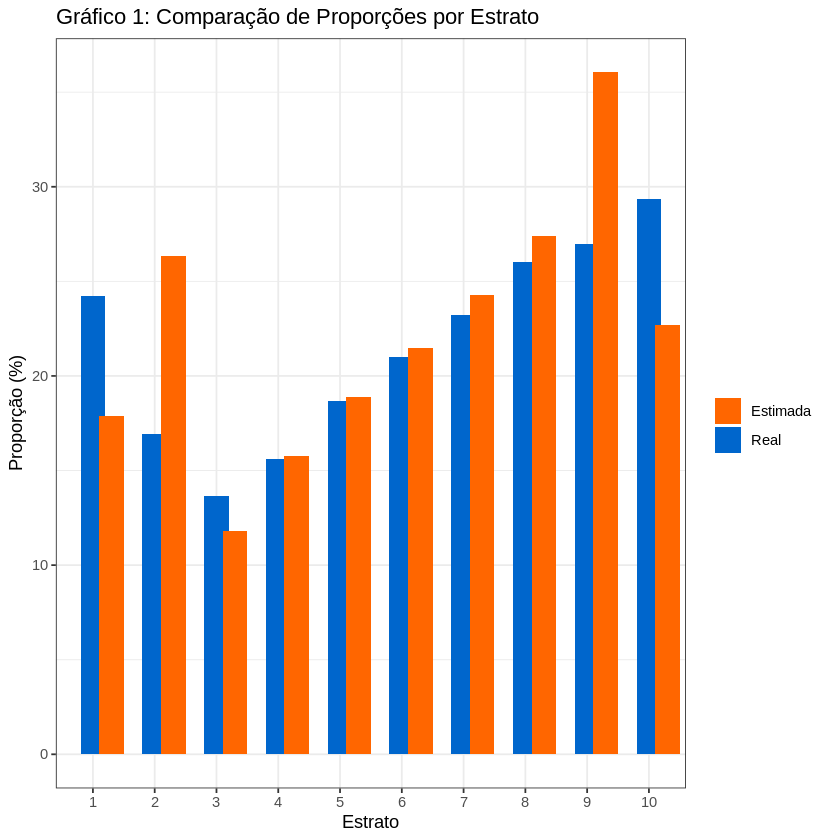

In [ ]:
print(grafico_comparacao_proporcao_estratos)

Podemos afirmar que, apesar de em alguns estratos as proporções estimadas serem um pouco discrepantes dos valores reais, no restante dos estratos, a proporção estimada obteve valores próximos aos reais, e como vimos no estimador final, obtivemos um resultado próximo à proporção real ($\hat{p}_{AES} \approx 0,22; p \approx 0,21$).

Além disso, uma observação muito interessante que pode ser feita a respeito da estratificação baseada na Questão 14 é o fato da proporção de pessoas aprovadas aumentar proporcionalmente ao aumento da renda familiar mensal. Logo, podemos dizer que o fator renda é uma grande influência na aprovação dos indíviduos, fator o qual favorece quem possui renda maior.

## **4. AASs vs. AES**

Já obtidos os parâmetros e estimadores da Amostragem Aleatória Simples e da Amostragem Estratificada, podemos verificar qual dos dois planos amostrais obteve uma precisão melhor na amostragem feita a fim de estimar o valor de indivíduos que passaram para a 2ª fase do processo seletivo.

In [ ]:
cat("\nTABELA 3: Comparação direta entre AAS e AES\n")
print(tabela_comparacao_direta)


TABELA 3: Comparação direta entre AAS e AES
# A tibble: 4 × 5
  Metodo Parametro Valor_Real Estimativa Variancia_Estimador
  <fct>  <fct>          <dbl>      <dbl>               <dbl>
1 AAS    Total      15390      16333.          562556.      
2 AAS    Proporcao      0.209      0.222            0.000104
3 AES    Total      15390      15575           562273.      
4 AES    Proporcao      0.209      0.222            0.000103


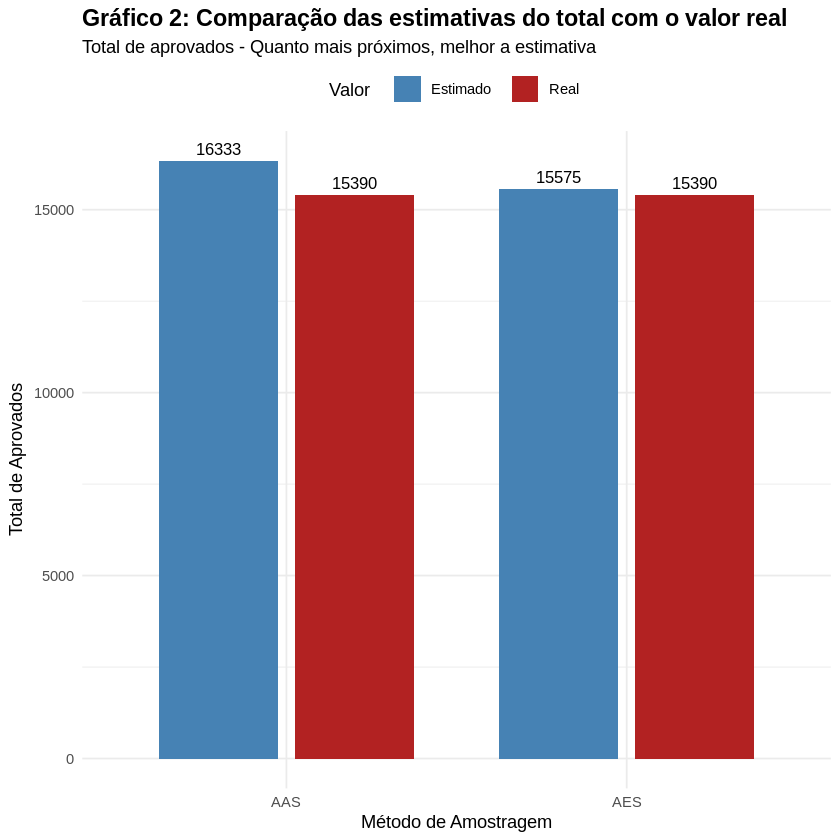

In [ ]:
print(grafico_comparacao_total)

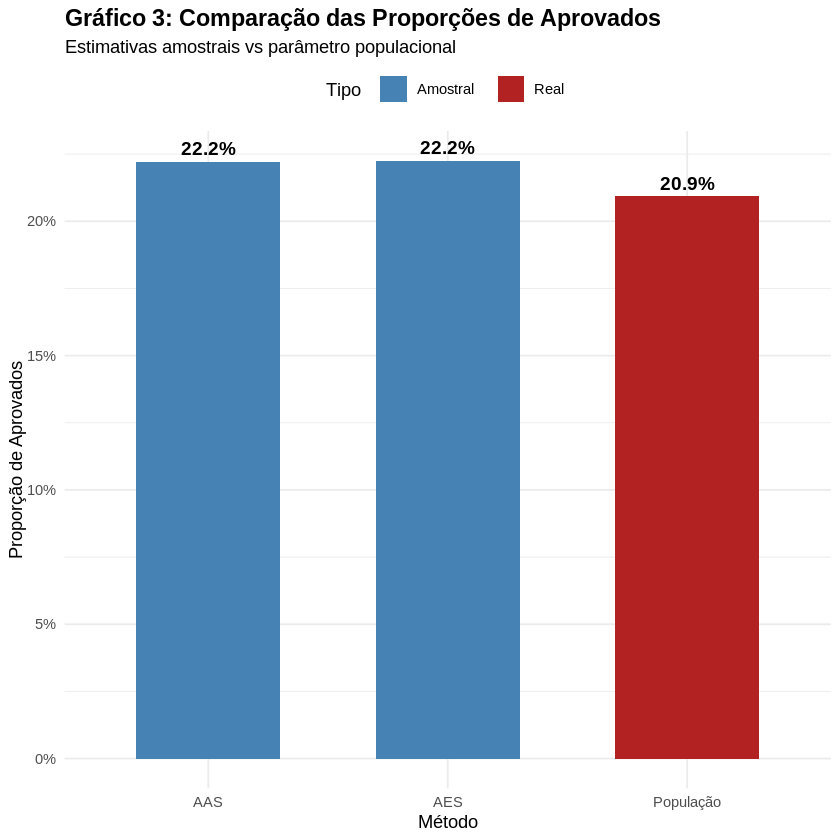

In [ ]:
print(grafico_comparacao_proporcao)

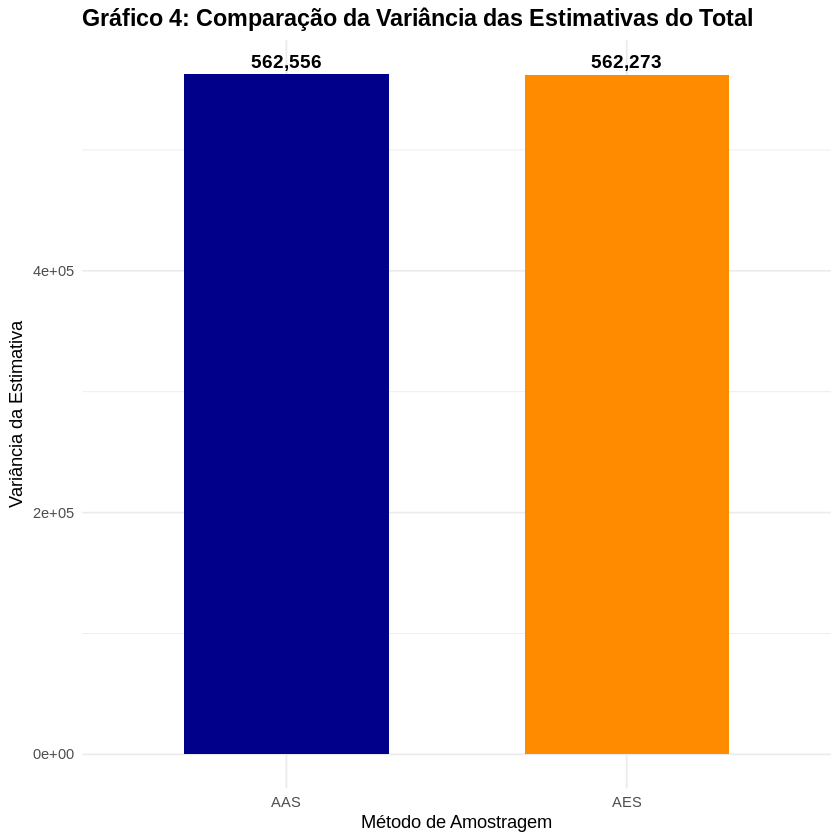

In [ ]:
print(grafico_variancias)

Como podemos observar na Tabela 3 e nos gráficos, ambos os métodos foram eficientes em estimar tanto o total de aprovados quanto a proporção, obtendo pouca diferença entre os valores reais e os estimados.
Porém, em um olhar mais minucioso, dois detalhes chamam atenção
* $\hat{p}_{AAS} \approx \hat{p}_{AES}$;
* $V_{AES}(\hat{N}_a)/V_{AAS}(\hat{N}_a) \approx 0,999$

Portanto, com base nesses dois fatos, podemos concluir que ambos planos amostrais apresentam quase a mesma eficiência quando o objetivo é estimar quantas pessoas passaram para a 2ª fase do processo seletivo, por apresentarem variâncias da estimativa do total e estimativas da proporção praticamente iguais. Apesar da estimativa do total para AES ser mais precisa que a estimativa de AES, esse fato pode ser relevado por conta do total $N$ ser muito grande e, como dito anteriormente, a variância dos estimadores ser semelhante.

Então, para aplicações reais dos planos amostrais, caso o fator custo seja relevante, a **Amostragem Aleatória Simples** se mostra um plano amostral melhor, por conta de ser usualmente mais barato comparado à AES por requisitar menos informações da população. Porém, a **Amostragem Estratificada** nos oferece outras informações que a AAS não fornece, como a influência da variável de estratificação no objetivo da amostragem. Por exemplo, nesse trabalho vimos que o fator renda influencia na aprovação do processo seletivo, algo que a AAS não conseguiria fornecer.

## **5. Apêndice**

### **Códigos feitos no R das tabelas utilizadas**

In [ ]:
#TABELA 1: Número de aprovados em cada estrato

tabela_aprovados_estratos_completa <- tibble(
  Estrato = 1:10,
  Q14 = as.character(0:9),
  Tamanho_Estrato = as.numeric(Nh),
  Aprovados_Populacao = as.numeric(Yh),
  Proporcao_Aprovados = round(as.numeric(Yh) / as.numeric(Nh), 2)
) %>%
  select(Estrato, Tamanho_Estrato, Aprovados_Populacao, Proporcao_Aprovados)

In [ ]:
#TABELA 2: Número de aprovados em cada amostra dos estratos

tabela_aprovados_amostra_completa <- tibble(
  Estrato = 1:10,
  Q14 = as.character(0:9),
  Aprovados_Amostra = as.numeric(th),
  Tamanho_Amostra = as.numeric(nh),
  Prop_Aprovados = round(as.numeric(th) / as.numeric(nh), 2)
) %>%
  select(Estrato, Tamanho_Amostra, Aprovados_Amostra, Prop_Aprovados)

In [ ]:
#TABELA 3: Comparação direta entre AAS e AES (parâmetros e estimativas)

tabela_comparacao_direta <- tibble(
  Metodo = rep(c("AAS", "AES"), each = 2),
  Parametro = rep(c("Total", "Proporcao"), 2),
  Valor_Real = rep(c(Y, Y_barra), 2),
  Estimativa = c(Y_chapeu, y_barra, Y_chapeu_AES, y_barra_AES),
  Variancia_Estimador = c(
    var_Y_chapeu, var_y_barra,
    var_Y_AES_chapeu, var_y_barra_AES
  )
) %>%
  mutate(
    Metodo = factor(Metodo, levels = c("AAS", "AES")),
    Parametro = factor(Parametro, levels = c("Total", "Proporcao"))
  )

### **Códigos feitos no R dos gráficos utilizados**

In [ ]:
#Gráfico 1: Comparação de proporção por estratos

grafico_comparacao_proporcao_estratos <- ggplot() +
  geom_col(aes(x = factor(1:10), y = as.numeric(Yh)/as.numeric(Nh) * 100,
               fill = "Real"), width = 0.4) +
  geom_col(aes(x = factor(1:10), y = as.numeric(th)/as.numeric(nh) * 100,
               fill = "Estimada"), width = 0.4,
           position = position_nudge(x = 0.3)) +
  labs(x = "Estrato", y = "Proporção (%)", fill = "",
       title = "Gráfico 1: Comparação de Proporções por Estrato") +
  scale_fill_manual(values = c("Real" = "#0066CC", "Estimada" = "#FF6600")) +
  scale_x_discrete(labels = 1:10) +
  theme_bw()

In [ ]:
#Gráfico 2: Comparação das estimativas do total com o valor real

grafico_comparacao_total <- ggplot(dados_comparacao_direta,
                                          aes(x = Metodo, y = Valor, fill = Tipo)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_text(aes(label = round(Valor)),
            position = position_dodge(width = 0.8),
            vjust = -0.5, size = 3.5) +
  labs(title = "Gráfico 2: Comparação das estimativas do total com o valor real",
       subtitle = "Total de aprovados - Quanto mais próximos, melhor a estimativa",
       x = "Método de Amostragem",
       y = "Total de Aprovados",
       fill = "Valor") +
  scale_fill_manual(values = c("Estimado" = "steelblue", "Real" = "firebrick")) +
  theme_minimal() +
  theme(legend.position = "top",
        plot.title = element_text(face = "bold", size = 14),
        plot.subtitle = element_text(size = 11))

In [ ]:
#Gráfico 3: Comparação das Proporções de Aprovados

dados_comparacao_proporcao <- data.frame(
  Metodo = c("AAS", "AES", "População"),
  Proporcao = c(y_barra, y_barra_AES, Y_barra),
  Tipo = c("Amostral", "Amostral", "Real")
)

grafico_comparacao_proporcao <- ggplot(dados_comparacao_proporcao,
                                       aes(x = Metodo, y = Proporcao, fill = Tipo)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0(round(Proporcao*100, 1), "%")),
            vjust = -0.5, size = 4, fontface = "bold") +
  labs(title = "Gráfico 3: Comparação das Proporções de Aprovados",
       subtitle = "Estimativas amostrais vs parâmetro populacional",
       x = "Método",
       y = "Proporção de Aprovados") +
  scale_fill_manual(values = c("Amostral" = "steelblue", "Real" = "firebrick")) +
  scale_y_continuous(labels = percent_format()) +
  theme_minimal() +
  theme(legend.position = "top",
        plot.title = element_text(face = "bold", size = 14),
        plot.subtitle = element_text(size = 11))

In [ ]:
#Gráfico 4: Comparação da Variância das Estimativas do Total

eficiencia <- var_Y_AES_chapeu / var_Y_chapeu

grafico_eficiencia <- data.frame(
  Metodo = c("AAS", "AES"),
  Variancia = c(var_Y_chapeu, var_Y_AES_chapeu)
)

grafico_variancias <- ggplot(grafico_eficiencia,
                             aes(x = Metodo, y = Variancia, fill = Metodo)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = format(round(Variancia), big.mark = ",")),
            vjust = -0.5, size = 4, fontface = "bold") +
  labs(title = "Gráfico 4: Comparação da Variância das Estimativas do Total",
       x = "Método de Amostragem",
       y = "Variância da Estimativa") +
  scale_fill_manual(values = c("AAS" = "darkblue", "AES" = "darkorange")) +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", size = 14),
        plot.subtitle = element_text(size = 11))